# Customer and log analytics for a gamedev startup

Project Simulation: In this project, I took on the role of an analyst for a gamedev startup that launched a simple game on the market: in the app, users try to guess the answers to presented questions. The dataset consists of two datasets: user_data and logs.

Data Description:

user_data:  

client – user identifier  
premium – whether the client has premium status  
age – age  

logs:  
client – user identifier  
success – answer result (operation): success = 1, no = 0  
platform – platform  
time – time in Unix format  

In [2]:
import pandas as pd

In [3]:
# define variables and read csv files
user_data = pd.read_csv('3_user_data.csv')
logs = pd.read_csv('3_logs.csv')

### Step 2
### Get some info from data

In [4]:
user_data.head()

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


In [5]:
logs.head()

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629


In [6]:
print(f"Shape of user_data is {user_data.shape}")
print(f"------------------------------------")
print(f"Shape of user_data is {logs.shape}")

Shape of user_data is (2954, 3)
------------------------------------
Shape of user_data is (4500, 4)


In [7]:
user_data.describe()

,client,age
count,2954.000000,2954.000000
mean,50767.886594,44.196005
std,28800.505847,14.248336
min,40.000000,20.000000
25%,25639.500000,32.000000
50%,51569.500000,44.000000
75%,75963.250000,56.000000
max,99973.000000,69.000000


In [8]:
logs.describe()

,client,time
count,4500.000000,4.500000e+03
mean,50998.758000,1.585440e+09
std,28374.472495,2.314866e+04
min,40.000000,1.585400e+09
25%,27056.500000,1.585420e+09
50%,52659.000000,1.585440e+09
75%,76001.250000,1.585461e+09
max,99993.000000,1.585480e+09


In [9]:
user_data.dtypes

client     int64
premium     bool
age        int64
dtype: object

In [10]:
logs.dtypes

client       int64
success       bool
platform    object
time         int64
dtype: object

In [11]:
user_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2954 entries, 0 to 2953
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   client   2954 non-null   int64
 1   premium  2954 non-null   bool 
 2   age      2954 non-null   int64
dtypes: bool(1), int64(2)
memory usage: 49.2 KB


In [12]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   client    4500 non-null   int64 
 1   success   4500 non-null   bool  
 2   platform  4500 non-null   object
 3   time      4500 non-null   int64 
dtypes: bool(1), int64(2), object(1)
memory usage: 110.0+ KB


### Step 3
### Determined which customer or customers provided the highest number of correct answers and listed their identifiers in ascending order, separated by commas and spaces.

In [ ]:
# filtered 'true'in success column and counted to each id
success_counts = logs.loc[logs.success == True].client.value_counts()
success_counts


client
28719    41
52870    41
61468    41
61473    41
12179    41
         ..
70028     1
37123     1
73522     1
38359     1
40921     1
Name: count, Length: 2845, dtype: int64

In [15]:
# figured out the customers' IDs with the highest number of correct answers
max_num = success_counts.max()
max_success_users = success_counts.loc[success_counts == max_num]
max_success_users.index.sort_values()

Index([12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584], dtype='int64', name='client')

### Step 4
### Which platform had the highest number of correct answers?

In [17]:
platform_success_counts = logs.loc[logs.success == True].platform.value_counts()
platform_success_counts

platform
phone       2019
computer    1090
tablet       180
Name: count, dtype: int64

In [18]:
platform_success_counts.idxmax()

'phone'

### Step 4
### Define which platform is the most popular among premium customers

In [20]:
# merge user_data
data = logs.merge(user_data, on= 'client')
data.head(10)

,client,success,platform,time,premium,age
0,61468,True,phone,1585425658,False,25
1,61468,True,computer,1585460504,False,25
2,61468,True,computer,1585430291,False,25
3,61468,True,computer,1585444317,False,25
4,61468,True,phone,1585441266,False,25
5,61468,True,phone,1585439167,False,25
6,61468,True,phone,1585409248,False,25
7,61468,True,computer,1585416826,False,25
8,61468,True,phone,1585414972,False,25
9,61468,True,phone,1585478036,False,25


In [ ]:
# filtered and counted 'True'
data.loc[data.premium == True].platform.value_counts().idxmax()

'phone'

### Step 5
### Created a chart using pyplot that shows the number of answers from premium customers on each platform (kept trying with pyplot)

In [29]:
import matplotlib.pyplot as plt

<BarContainer object of 3 artists>

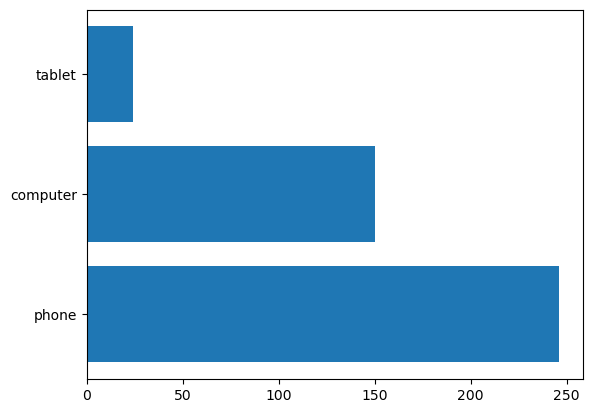

In [30]:
premium_user_platform = data.loc[data.premium == True].platform.value_counts()
plt.barh(premium_user_platform.index, premium_user_platform.values)

### Step 6
### Check the share of incorrect answers among all answers, separating premium and regular customers. Which category of customers has a higher share of incorrect answers?

In [31]:
success_premium = data.groupby(['premium', 'success'], as_index=False).agg({'client':'count'})\
    .pivot(index='premium', columns='success', values='client')
success_premium

success,False,True
premium,,
False,775,2244
True,117,303


In [32]:
success_premium['percent_unsuccessful'] = success_premium[False] / (success_premium[False] + success_premium[True])
success_premium

success,False,True,percent_unsuccessful
premium,,,
False,775,2244,0.256708
True,117,303,0.278571


### Step 7
### To compare the age distribution between premium and regular customers, created two histograms in the same space using the plt.subplot() function from the matplotlib library

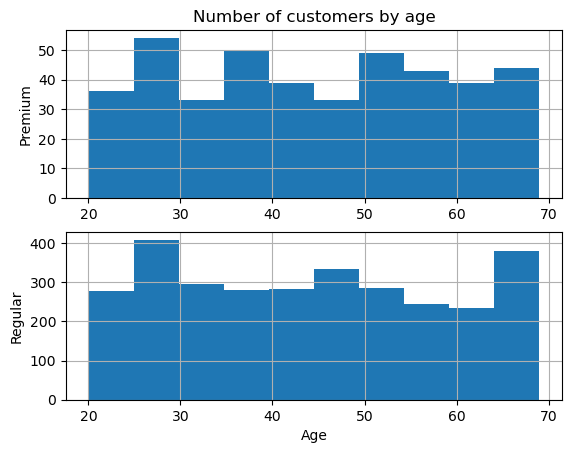

In [39]:
plt.subplot(2, 1, 1)

plt.hist(data.query('premium == True').age)
plt.title("Number of customers by age")
plt.ylabel("Premium")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.hist(data.query('premium == False').age)
plt.xlabel("Age")
plt.ylabel("Regular")
plt.grid(True)

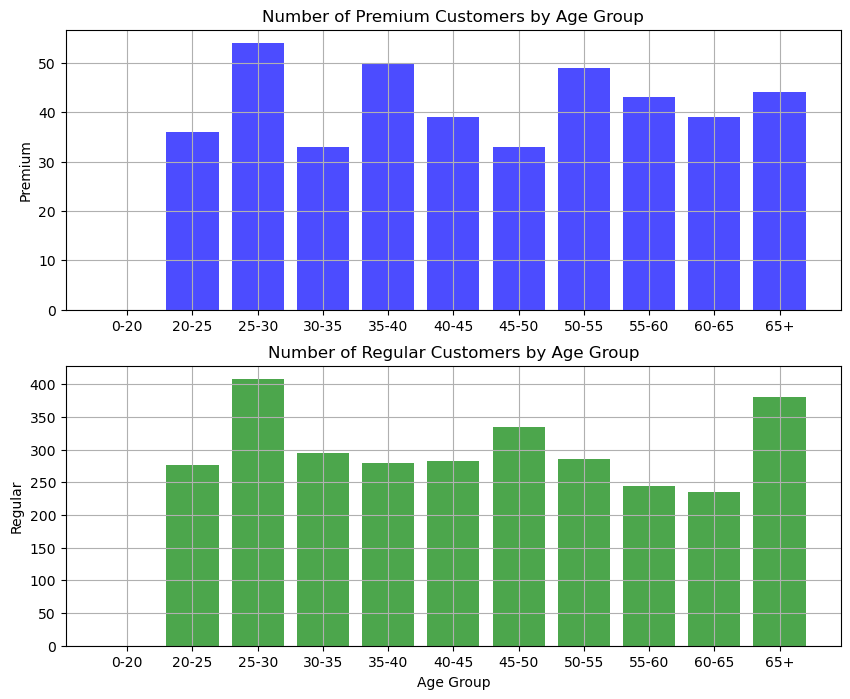

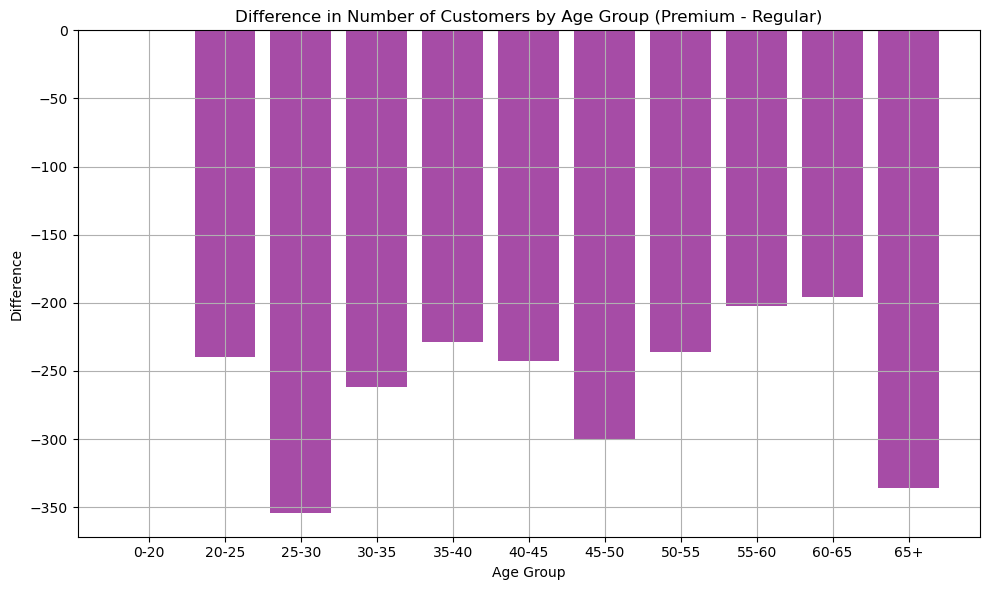

In [53]:
# split the data 
premium_data = data.query('premium == True').age
regular_data = data.query('premium == False').age

# age groups
bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]  # Age bins
labels = ['0-20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65+']

# count of customers
premium_age_groups = pd.cut(premium_data, bins=bins, labels=labels, right=False).value_counts().sort_index()
regular_age_groups = pd.cut(regular_data, bins=bins, labels=labels, right=False).value_counts().sort_index()

# 
plt.figure(figsize=(10, 8))

# premium
plt.subplot(2, 1, 1)
plt.bar(premium_age_groups.index, premium_age_groups.values, alpha=0.7, label='Premium', color='blue')
plt.title("Number of Premium Customers by Age Group")
plt.ylabel("Premium")
plt.xticks(rotation=0)
plt.grid(True)

# regular
plt.subplot(2, 1, 2)
plt.bar(regular_age_groups.index, regular_age_groups.values, alpha=0.7, label='Regular', color='green')
plt.title("Number of Regular Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Regular")
plt.xticks(rotation=0)
plt.grid(True)

# plot the difference
plt.figure(figsize=(10, 6))
age_groups_diff = premium_age_groups - regular_age_groups
plt.bar(age_groups_diff.index, age_groups_diff.values, alpha=0.7, color='purple')
plt.title("Difference in Number of Customers by Age Group (Premium - Regular)")
plt.xlabel("Age Group")
plt.ylabel("Difference")
plt.xticks(rotation=0)  
plt.grid(True) 

# Adjust layout to avoid clipping of content
plt.tight_layout()
plt.show()

### Step 8
### Created a graph showing the number of correct answers per user

In [54]:
import seaborn as sns

<Axes: xlabel='success', ylabel='count'>

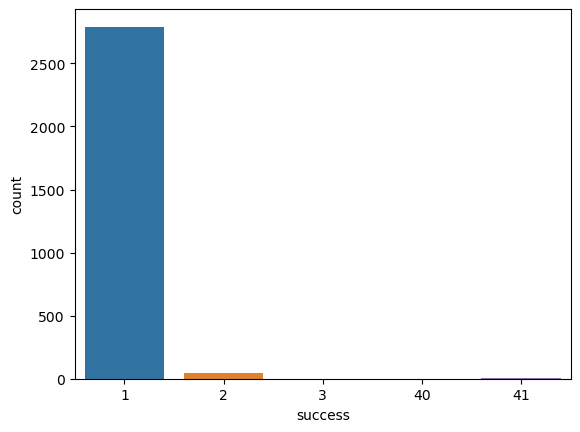

In [55]:
success_count = logs.loc[logs.success == True].client.value_counts().rename('success')
sns.countplot(x=success_count)

### Step 9
### Created a graph showing the number of correct answers made on the computer platform by age.

<Axes: xlabel='age', ylabel='count'>

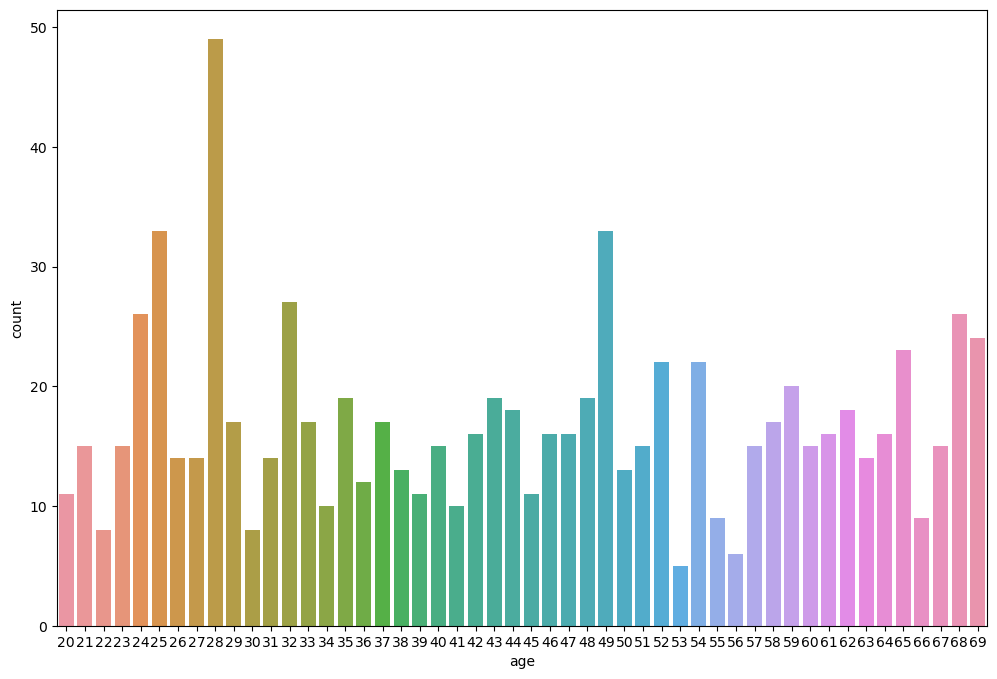

In [56]:
success_computer = data.query('platform == "computer" and success == True')


plt.figure(figsize =(12, 8))
sns.countplot(data=success_computer, x='age')